# ***ARYAN KHAN | 17 | 221A036***

In [ ]:
# ARYAN KHAN | 17 | 221A036
import os
import gymnasium as gym
import numpy as np

In [ ]:
# ARYAN KHAN | 17 | 221A036
env = gym.make("Taxi-v3", render_mode = "rgb_array")

In [ ]:
# ARYAN KHAN | 17 | 221A036
state = env.reset()

In [ ]:
# ARYAN KHAN | 17 | 221A036
state

(267, {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

In [ ]:
# ARYAN KHAN | 17 | 221A036
env.observation_space.n

np.int64(500)

In [ ]:
# ARYAN KHAN | 17 | 221A036
env.action_space.n

np.int64(6)

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
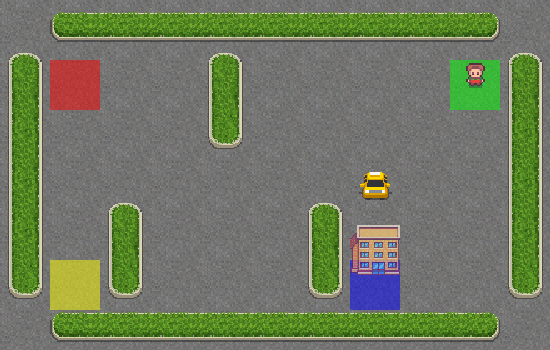

In [ ]:
# ARYAN KHAN | 17 | 221A036
env.render()

In [ ]:
# ARYAN KHAN | 17 | 221A036
env.step(1)

(167,
 -1,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

In [ ]:
# ARYAN KHAN | 17 | 221A036
env.step(5)

(167,
 -10,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

In [ ]:
# ARYAN KHAN | 17 | 221A036
n_states = env.observation_space.n
n_actions = env.action_space.n

In [ ]:
# ARYAN KHAN | 17 | 221A036
n_actions

np.int64(6)

In [ ]:
# ARYAN KHAN | 17 | 221A036
state = env.reset()
counter = 0
g = 0
reward = None

In [ ]:
# ARYAN KHAN | 17 | 221A036
while reward!= 20:
  state, reward, terminated, truncated, info = env.step(env.action_space.sample())
  done = terminated or truncated
  counter+= 1
  g+= reward

In [ ]:
print("Solved in {} steps with a total reward of {}".format(counter,g))

Solved in 2147 steps with a total reward of -8516


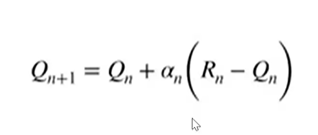

In [ ]:
# ARYAN KHAN | 17 | 221A036
Q = np.zeros([n_states, n_actions])

In [ ]:
# ARYAN KHAN | 17 | 221A036
n_actions

np.int64(6)

In [ ]:
# ARYAN KHAN | 17 | 221A036
episodes = 1
G = 0
alpha = 0.618

In [ ]:
# ARYAN KHAN | 17 | 221A036
for episode in range(1, episodes+1):
  done = False
  G, reward = 0,0 # Initialize G and reward correctly
  # env.reset() returns a tuple (observation, info), we only need the observation
  state, info = env.reset()
  finalState = state # finalState should also be an integer
  print("Initial state {}".format(state))
  while reward != 20:
    action = np.argmax(Q[state]) # Use the integer state for indexing
    # env.step() returns (observation, reward, terminated, truncated, info)
    state2, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated # update done status
    Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
    G += reward
    state = state2 # Update state to the new integer state

Initial state 261


In [ ]:
# ARYAN KHAN | 17 | 221A036
finalState = state

In [ ]:
# ARYAN KHAN | 17 | 221A036
finalState

85

In [ ]:
# ARYAN KHAN | 17 | 221A036
G

-2254

In [ ]:
# ARYAN KHAN | 17 | 221A036
episodes = 2000
rewardTracker = []

G = 0
alpha = 0.618

for episode in range(1, episodes+1):
  done = False
  G, reward = 0,0
  # Correctly unpack state and info from env.reset()
  state, info = env.reset()

  while done != True:
    action = np.argmax(Q[state])
    # Correctly unpack all 5 values from env.step() and set 'done'
    state2, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    Q[state, action] += alpha * (reward + np.max(Q[state2]) - Q[state, action])
    G += reward
    state = state2

    if episode % 100 == 0:
      print(f"Episode {episode} Total Reward: {G}")

Episode 100 Total Reward: -1
Episode 100 Total Reward: -2
Episode 100 Total Reward: -3
Episode 100 Total Reward: -4
Episode 100 Total Reward: -5
Episode 100 Total Reward: -6
Episode 100 Total Reward: -7
Episode 100 Total Reward: -8
Episode 100 Total Reward: -9
Episode 100 Total Reward: -10
Episode 100 Total Reward: -11
Episode 100 Total Reward: -12
Episode 100 Total Reward: -13
Episode 100 Total Reward: -14
Episode 100 Total Reward: -15
Episode 100 Total Reward: -16
Episode 100 Total Reward: -17
Episode 100 Total Reward: -18
Episode 100 Total Reward: -19
Episode 100 Total Reward: -20
Episode 100 Total Reward: -21
Episode 100 Total Reward: -22
Episode 100 Total Reward: -23
Episode 100 Total Reward: -24
Episode 100 Total Reward: -25
Episode 100 Total Reward: -26
Episode 100 Total Reward: -27
Episode 100 Total Reward: -28
Episode 100 Total Reward: -29
Episode 100 Total Reward: -30
Episode 100 Total Reward: -31
Episode 100 Total Reward: -32
Episode 100 Total Reward: -33
Episode 100 Total R